In [ ]:
!pip install kaggle


In [ ]:
import json
import os

username = "vladschiopu"
key = "KGAT_6e723a353a3d88b1430f9e215d771164"

kaggle_data = {"username": username, "key": key}

os.makedirs(os.path.expanduser("~/.config/kaggle"), exist_ok=True)

with open(os.path.expanduser("~/.config/kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_data, f)

!chmod 600 ~/.config/kaggle/kaggle.json

In [ ]:
!kaggle datasets list --user vladschiopu

ref                               title                       size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------  --------------------  ----------  --------------------------  -------------  ---------  ---------------  
vladschiopu/tema2ml-imagebits     Tema2ML_imagebits      232636120  2025-12-24 22:33:26.900000              0          0  0.0              
vladschiopu/tema2ml-land-patches  Tema2ML_land_patches    35276784  2025-12-24 22:34:53.877000              0          0  0.0              
vladschiopu/date-tema1is-1        Date_Tema1IS_1        2038331599  2025-11-22 16:18:57.673000             12          0  0.11764706       


In [ ]:
!kaggle datasets download -d vladschiopu/tema2ml-imagebits

Dataset URL: https://www.kaggle.com/datasets/vladschiopu/tema2ml-imagebits
License(s): unknown
 80% 178M/222M [00:00<00:00, 949MB/s] 
100% 222M/222M [00:00<00:00, 653MB/s]


In [ ]:
!kaggle datasets download -d vladschiopu/tema2ml-land-patches

Dataset URL: https://www.kaggle.com/datasets/vladschiopu/tema2ml-land-patches
License(s): unknown
  0% 0.00/33.6M [00:00<?, ?B/s]
100% 33.6M/33.6M [00:00<00:00, 757MB/s]


In [ ]:
import os
if not os.path.exists("dataset_imagebits"):
  !unzip tema2ml-imagebits.zip -d dataset_imagebits
if not os.path.exists("dataset_land_patches"):
  !unzip tema2ml-land-patches.zip -d dataset_land_patches

Streaming output truncated to the last 5000 lines.
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_1402.jpg  
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_1406.jpg  
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_141.jpg  
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_1410.jpg  
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_1412.jpg  
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_142.jpg  
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_1422.jpg  
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_1426.jpg  
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_1431.jpg  
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_1433.jpg  
  inflating: dataset_land_patches/land_patches/test/Residential/Residential_1435.

In [ ]:
import os

mapping = {
    "1": "airplane",
    "2": "bird",
    "3": "car",
    "4": "cat",
    "5": "deer",
    "6": "dog",
    "7": "horse",
    "8": "monkey",
    "9": "ship",
    "10": "truck"
}

base_path = "dataset_imagebits/imagebits"

for split in ["train", "test"]:
    split_path = os.path.join(base_path, split)
    for old, new in mapping.items():
        old_path = os.path.join(split_path, old)
        new_path = os.path.join(split_path, new)
        if os.path.exists(old_path):
            os.rename(old_path, new_path)


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader, random_split

train_path_imagebits = "dataset_imagebits/imagebits/train"
test_path_imagebits  = "dataset_imagebits/imagebits/test"

train_full_imagebits = datasets.ImageFolder(root=train_path_imagebits, transform=None)
test_dataset_imagebits = datasets.ImageFolder(root=test_path_imagebits, transform=None)

train_size_imagebits = int(0.8 * len(train_full_imagebits))
val_size_imagebits = len(train_full_imagebits) - train_size_imagebits

train_dataset_imagebits, val_dataset_imagebits = random_split(
    train_full_imagebits,
    [train_size_imagebits, val_size_imagebits]
)

train_loader_imagebits = DataLoader(train_dataset_imagebits, batch_size=32, shuffle=True)
val_loader_imagebits   = DataLoader(val_dataset_imagebits, batch_size=32, shuffle=False)
test_loader_imagebits  = DataLoader(test_dataset_imagebits, batch_size=32, shuffle=False)

print(train_full_imagebits.classes)
print(train_full_imagebits.class_to_idx)



['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
{'airplane': 0, 'bird': 1, 'car': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'horse': 6, 'monkey': 7, 'ship': 8, 'truck': 9}


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

train_path_land_patches = "dataset_land_patches/land_patches/train"
val_path_land_patches   = "dataset_land_patches/land_patches/val"
test_path_land_patches  = "dataset_land_patches/land_patches/test"

train_dataset_land_patches = datasets.ImageFolder(root=train_path_land_patches, transform=None)
val_dataset_land_patches   = datasets.ImageFolder(root=val_path_land_patches, transform=None)
test_dataset_land_patches  = datasets.ImageFolder(root=test_path_land_patches, transform=None)

train_loader_land_patches = DataLoader(train_dataset_land_patches, batch_size=32, shuffle=True)
val_loader_land_patches   = DataLoader(val_dataset_land_patches, batch_size=32, shuffle=False)
test_loader_land_patches  = DataLoader(test_dataset_land_patches, batch_size=32, shuffle=False)

print(train_dataset_land_patches.classes)
print(train_dataset_land_patches.class_to_idx)


['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


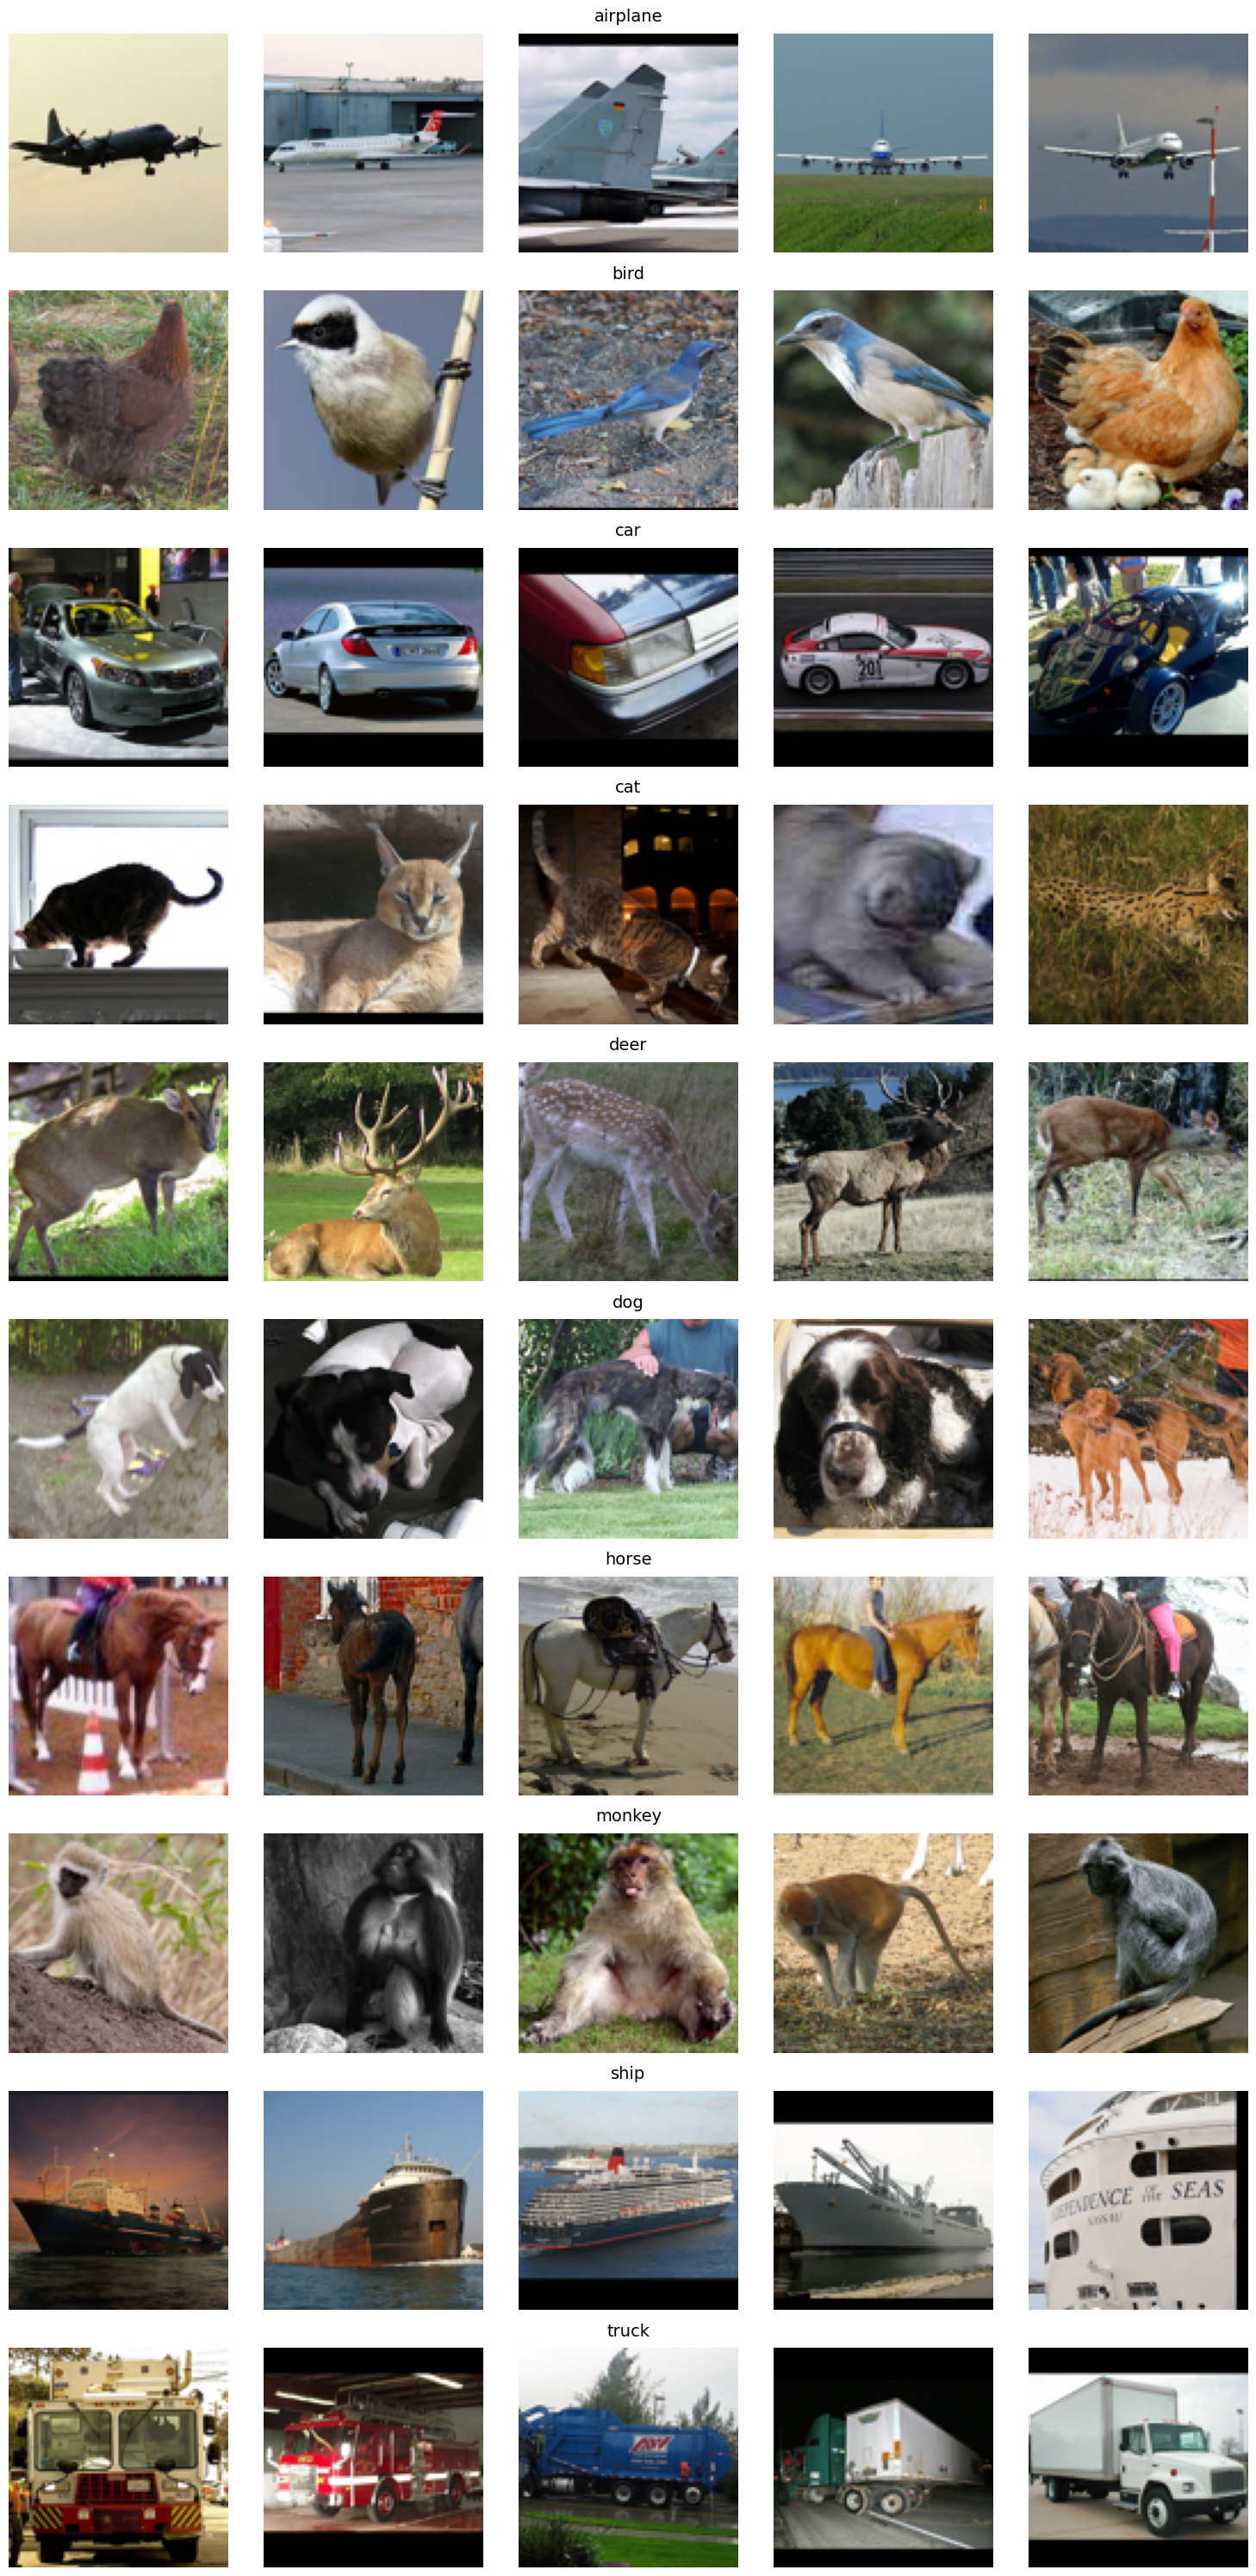

In [ ]:
import matplotlib.pyplot as plt

import random
import matplotlib.pyplot as plt

def show_samples_per_class(dataset, samples_per_class=5):
    classes = dataset.classes
    collected = {cls: [] for cls in classes}

    all_by_class = {cls: [] for cls in classes}
    for img, label in dataset:
        cls = classes[label]
        all_by_class[cls].append(img)

    for cls in classes:
        collected[cls] = random.sample(all_by_class[cls], samples_per_class)

    num_classes = len(classes)
    fig, axes = plt.subplots(
        num_classes,
        samples_per_class,
        figsize=(samples_per_class * 3, num_classes * 3)
    )

    for row, cls in enumerate(classes):
        for col in range(samples_per_class):
            axes[row, col].imshow(collected[cls][col])
            axes[row, col].axis("off")
            if col == samples_per_class // 2:
                axes[row, col].set_title(cls, fontsize=14, pad=10)

    plt.tight_layout()
    plt.show()



show_samples_per_class(train_full_imagebits, samples_per_class=5)


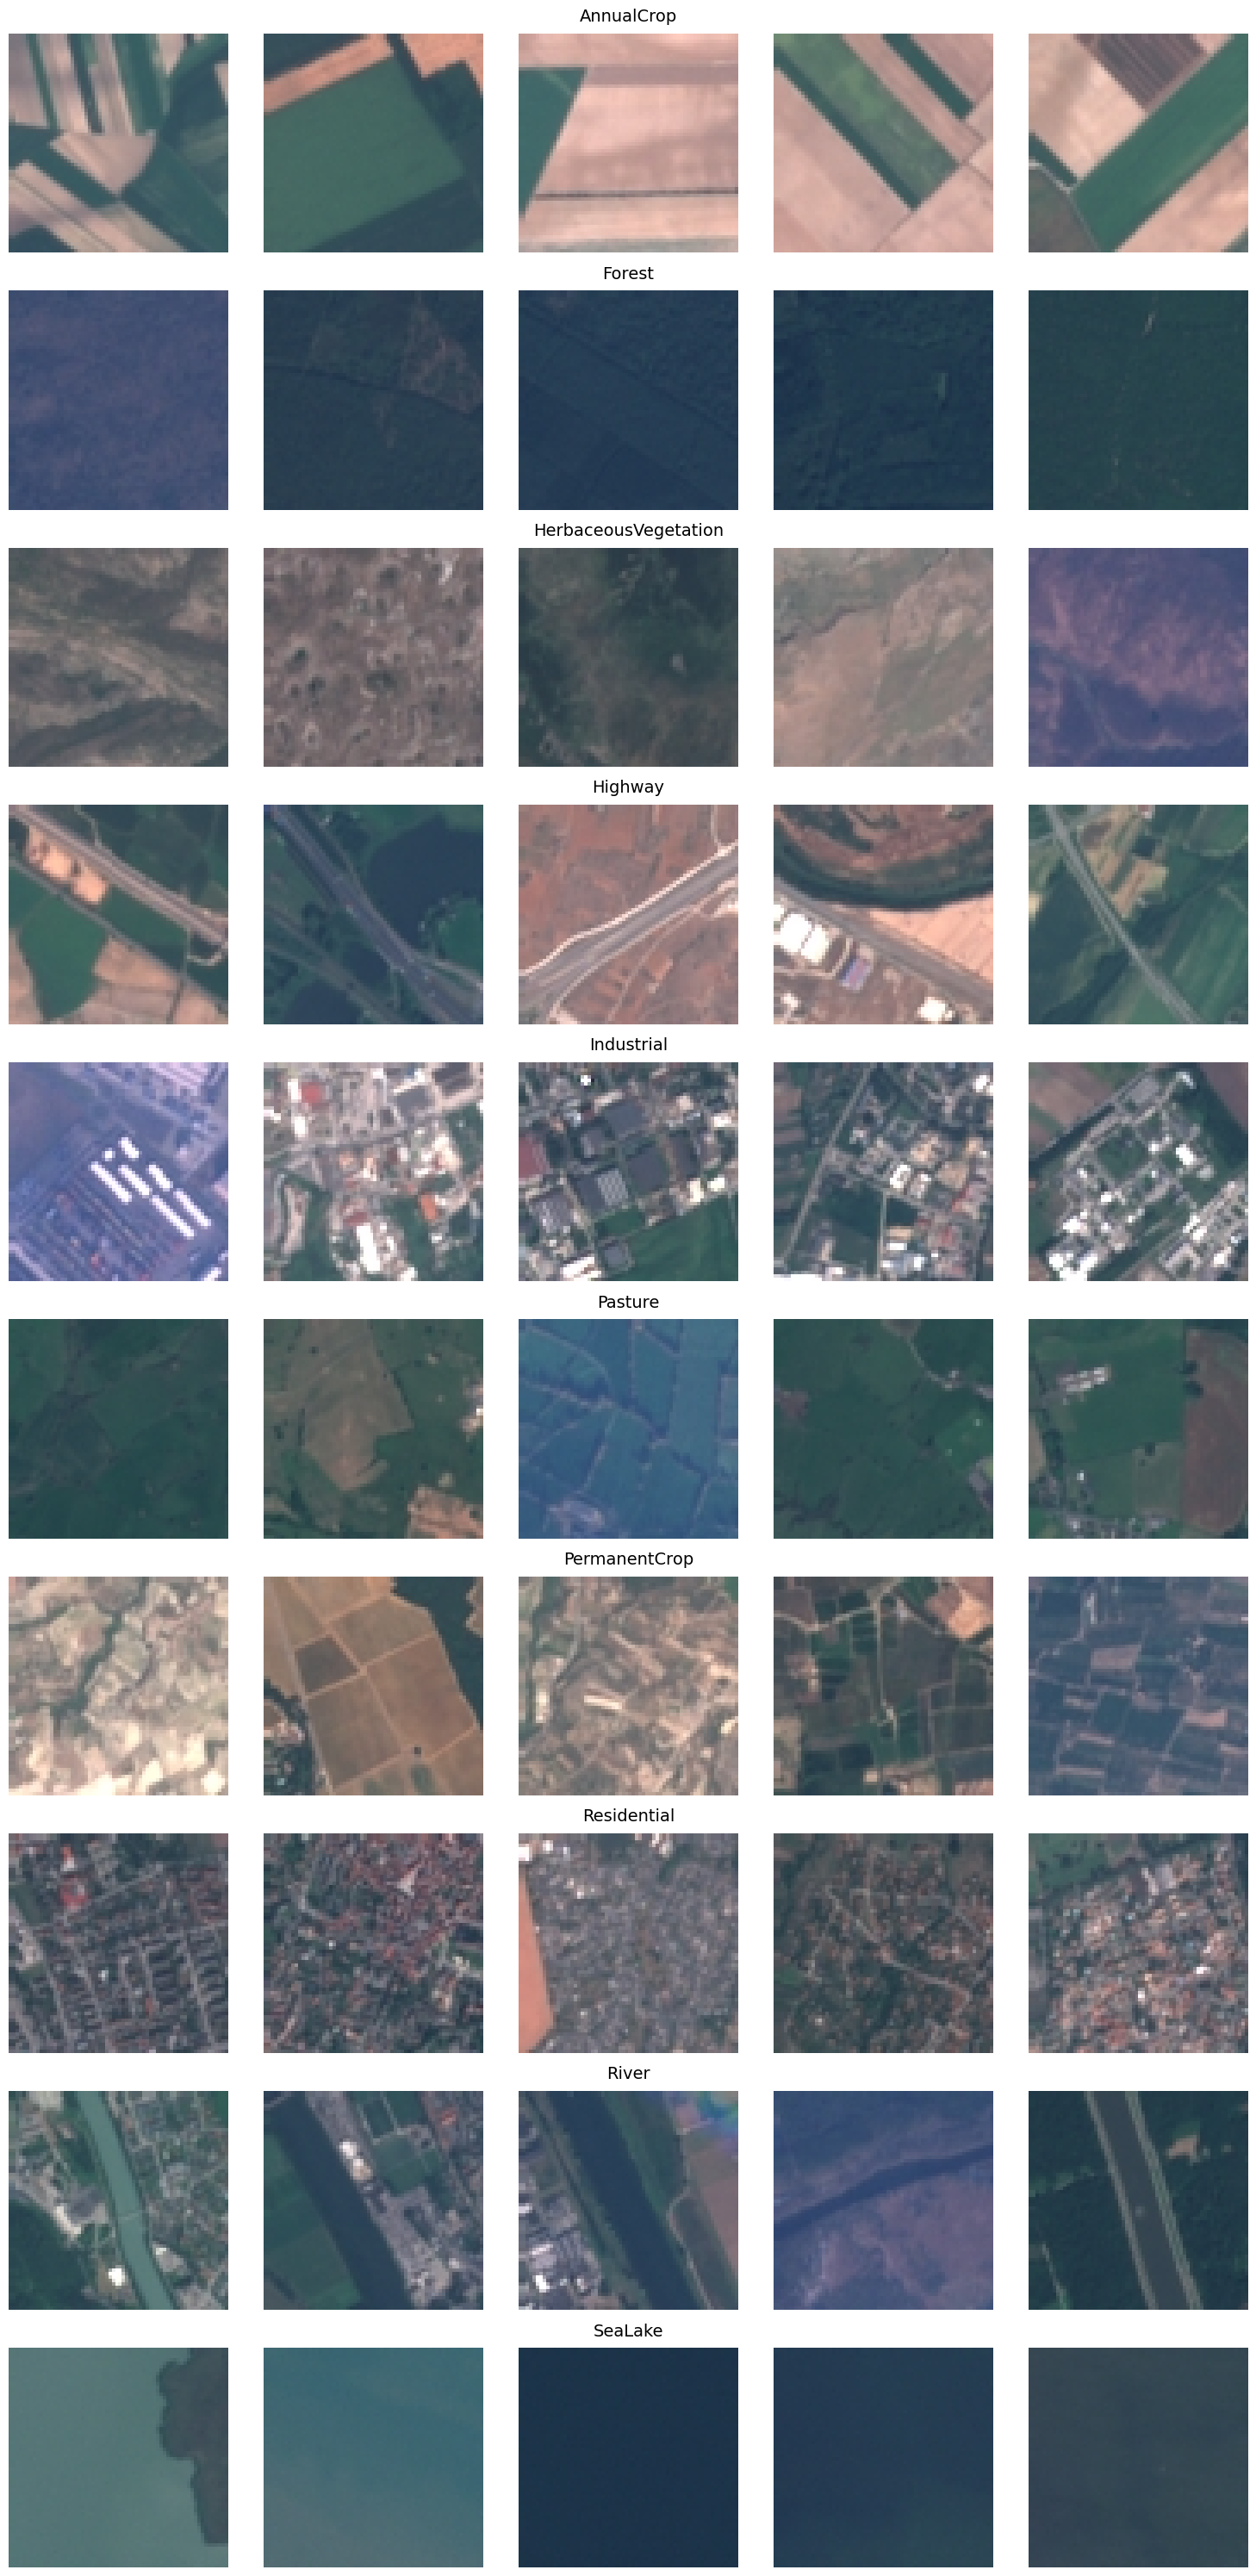

In [ ]:
show_samples_per_class(train_dataset_land_patches, samples_per_class=5)

In [ ]:
from collections import Counter

labels = [label for _, label in train_full_imagebits]
counter = Counter(labels)

print(f"train_full_imagebits\n")

for cls_idx, count in counter.items():
    print(f"Clasa {train_full_imagebits.classes[cls_idx]}: {count} imagini")

print(f"\n")
print(f"test_dataset_imagebits\n")

labels = [label for _, label in test_dataset_imagebits]
counter = Counter(labels)

for cls_idx, count in counter.items():
    print(f"Clasa {test_dataset_imagebits.classes[cls_idx]}: {count} imagini")

print(f"\n")
print(f"train_dataset_land_patches\n")

labels = [label for _, label in train_dataset_land_patches]
counter = Counter(labels)

for cls_idx, count in counter.items():
    print(f"Clasa {train_dataset_land_patches.classes[cls_idx]}: {count} imagini")


print(f"\n")
print(f"test_dataset_land_patches\n")

labels = [label for _, label in test_dataset_land_patches]
counter = Counter(labels)

for cls_idx, count in counter.items():
    print(f"Clasa {test_dataset_land_patches.classes[cls_idx]}: {count} imagini")

train_full_imagebits

Clasa airplane: 800 imagini
Clasa bird: 800 imagini
Clasa car: 800 imagini
Clasa cat: 800 imagini
Clasa deer: 800 imagini
Clasa dog: 800 imagini
Clasa horse: 800 imagini
Clasa monkey: 800 imagini
Clasa ship: 800 imagini
Clasa truck: 800 imagini


test_dataset_imagebits

Clasa airplane: 500 imagini
Clasa bird: 500 imagini
Clasa car: 500 imagini
Clasa cat: 500 imagini
Clasa deer: 500 imagini
Clasa dog: 500 imagini
Clasa horse: 500 imagini
Clasa monkey: 500 imagini
Clasa ship: 500 imagini
Clasa truck: 500 imagini


train_dataset_land_patches

Clasa AnnualCrop: 200 imagini
Clasa Forest: 200 imagini
Clasa HerbaceousVegetation: 200 imagini
Clasa Highway: 200 imagini
Clasa Industrial: 200 imagini
Clasa Pasture: 200 imagini
Clasa PermanentCrop: 200 imagini
Clasa Residential: 200 imagini
Clasa River: 200 imagini
Clasa SeaLake: 200 imagini


test_dataset_land_patches

Clasa AnnualCrop: 700 imagini
Clasa Forest: 700 imagini
Clasa HerbaceousVegetation: 700 imagini
Clasa Highw

#Imagebits

Clasele din seturile de date sunt echilibrate si exista acelasi numar de exemple pentru fiecare clasa.


##Similaritate Intra-clasa

Exemplele sunt foarte variate. Imaginile surprind obiectul in pozitii diferite, de la distante diferite, cu fundaluri diferite si cu iluminari diferite. Modelul de clasificare trebuie sa fie robust si sa ia in calcul toate aceste diferente.

##Similaritate Inter-clase

Putem observa cateva exemple care pot sa fie foarte similare in unele clase:

-cat, dog, deer si horse sunt surprinsi in general stand pe sol si sunt inconjurati de natura.

-monkey si bird pot semana din cauza ca stau in copaci

-airplane si ship seamana mai intai prin prezenta cerului si sunt unele exemple la airplane in care apare si apa

In plus rezolutia scazuta a pozelor face dificila detectarea detaliiilor.



#Land Patches

Clasele din seturile de date sunt echilibrate si exista acelasi numar de exemple pentru fiecare clasa.

In setul de date land_patches exista in setul de train 200 de exemple per clasa, si in setul de test exista 700.

Posibil sa fie o greseala aici si sa trebuiasca inlocuite folderele.


##Similaritate Intra-clasa

Aici exemplele din fiecare clasa nu mai variaza asa mult intre ele. Se observa niste tipare clare la unele clase cum ar fi:

-Forest (nuanta uniforma de verde)

-SeaLake (nuanta uniforma de albastru)

-Highway (curbe gri)

##Similaritate Inter-clase

Exista cateva similaritati usoare intre clase cum ar fi

-Forest si Pasture (predominant verde)

-Forest si SeaLake (lipsa detaliilor)

-AnnualCrop si PermanentCrop (organizarea in dreptunghiuri si culori asemanatoare)

#Antrenarea retelelor

##MLP

##Imagebits


In [ ]:
import numpy as np
from torch.utils.data import Dataset

class AlbumentationsImageFolder(Dataset):
    def __init__(self, image_folder, transform=None):
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.image_folder)

    def __getitem__(self, idx):
        image, label = self.image_folder[idx]

        image = np.array(image)

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, label


In [ ]:
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGEBITS_SIZE = 96

DATA_MEAN = (0.5, 0.5, 0.5)
DATA_STD  = (0.5, 0.5, 0.5)

USE_ALBUMENTATIONS = True

transform_imagebits = transforms.Compose([
    transforms.Resize((IMAGEBITS_SIZE, IMAGEBITS_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(DATA_MEAN, DATA_STD)
])


albumentations_train_imagebits = A.Compose([
    A.RandomResizedCrop(
        size=(96, 96),
        scale=(0.8, 1.0)
    ),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
        p=0.5
    ),
    A.Normalize(mean=DATA_MEAN, std=DATA_STD),
    ToTensorV2()
])


albumentations_test_imagebits = A.Compose([
    A.Resize(height=96, width=96),
    A.Normalize(mean=DATA_MEAN, std=DATA_STD),
    ToTensorV2()
])


train_full_imagebits = datasets.ImageFolder(
    root=train_path_imagebits,
    transform=None
)

test_imagebits = datasets.ImageFolder(
    root=test_path_imagebits,
    transform=None
)

train_size_imagebits = int(0.8 * len(train_full_imagebits))
val_size_imagebits = len(train_full_imagebits) - train_size_imagebits

train_subset, val_subset = random_split(
    train_full_imagebits,
    [train_size_imagebits, val_size_imagebits]
)

if USE_ALBUMENTATIONS:
    train_dataset_imagebits = AlbumentationsImageFolder(
        train_subset,
        transform=albumentations_train_imagebits
    )

    val_dataset_imagebits = AlbumentationsImageFolder(
        val_subset,
        transform=albumentations_test_imagebits
    )

    test_dataset_imagebits = AlbumentationsImageFolder(
        test_imagebits,
        transform=albumentations_test_imagebits
    )

else:
    train_subset.dataset.transform = transform_imagebits
    val_subset.dataset.transform   = transform_imagebits
    test_imagebits.transform  = transform_imagebits

    train_dataset_imagebits = train_subset
    val_dataset_imagebits   = val_subset
    test_dataset_imagebits  = test_imagebits


train_loader_imagebits = DataLoader(train_dataset_imagebits, batch_size=128, shuffle=True)
val_loader_imagebits   = DataLoader(val_dataset_imagebits, batch_size=128, shuffle=False)
test_loader_imagebits  = DataLoader(test_dataset_imagebits, batch_size=128, shuffle=False)



In [ ]:
import torch.nn as nn

# class MLP_ImageBits(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()

#         self.flatten = nn.Flatten()

#         self.fc1 = nn.Linear(3 * 96 * 96, 1024)
#         self.fc2 = nn.Linear(1024, 512)
#         self.fc3 = nn.Linear(512, num_classes)

#         self.relu = nn.ReLU()
#         self.dropout = nn.Dropout(p=0.3)

#     def forward(self, x):
#         x = self.flatten(x)
#         x = self.relu(self.fc1(x))
#         x = self.dropout(x)
#         x = self.relu(self.fc2(x))
#         x = self.dropout(x)
#         x = self.fc3(x)
#         return x


class MLP_ImageBits(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3 * 96 * 96, 1024)
        self.bn1 = nn.BatchNorm1d(1024)

        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)

        self.fc3 = nn.Linear(512, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MLP_ImageBits(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[10, 15],
    gamma=0.1
)

images, labels = next(iter(train_loader_imagebits))
images = images.to(device)

outputs = model(images)
print(outputs.shape)



torch.Size([128, 10])


In [ ]:
def evaluate_loss_and_acc(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    acc = correct / total
    return avg_loss, acc




train_losses, val_losses = [], []
train_accs, val_accs = [], []

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader_imagebits:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader_imagebits)
    train_acc = correct / total

    val_loss, val_acc = evaluate_loss_and_acc(
        model, val_loader_imagebits, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )

torch.save(model.state_dict(), "mlp_imagebits_pretrained.pth")


Epoch 01 | Train loss: 1.9070, acc: 0.2953 | Val loss: 1.7290, acc: 0.3481
Epoch 02 | Train loss: 1.7406, acc: 0.3489 | Val loss: 1.6496, acc: 0.3806
Epoch 03 | Train loss: 1.6737, acc: 0.3820 | Val loss: 1.5963, acc: 0.3975
Epoch 04 | Train loss: 1.6267, acc: 0.4023 | Val loss: 1.5585, acc: 0.4138
Epoch 05 | Train loss: 1.6001, acc: 0.4084 | Val loss: 1.5325, acc: 0.4206
Epoch 06 | Train loss: 1.5679, acc: 0.4230 | Val loss: 1.5572, acc: 0.4225
Epoch 07 | Train loss: 1.5372, acc: 0.4338 | Val loss: 1.5211, acc: 0.4338
Epoch 08 | Train loss: 1.5141, acc: 0.4423 | Val loss: 1.4788, acc: 0.4619
Epoch 09 | Train loss: 1.5004, acc: 0.4458 | Val loss: 1.4778, acc: 0.4587
Epoch 10 | Train loss: 1.4670, acc: 0.4619 | Val loss: 1.4701, acc: 0.4550
Epoch 11 | Train loss: 1.3984, acc: 0.4936 | Val loss: 1.4177, acc: 0.4744
Epoch 12 | Train loss: 1.3785, acc: 0.4944 | Val loss: 1.4011, acc: 0.4844
Epoch 13 | Train loss: 1.3464, acc: 0.5097 | Val loss: 1.3962, acc: 0.4838
Epoch 14 | Train loss: 1.

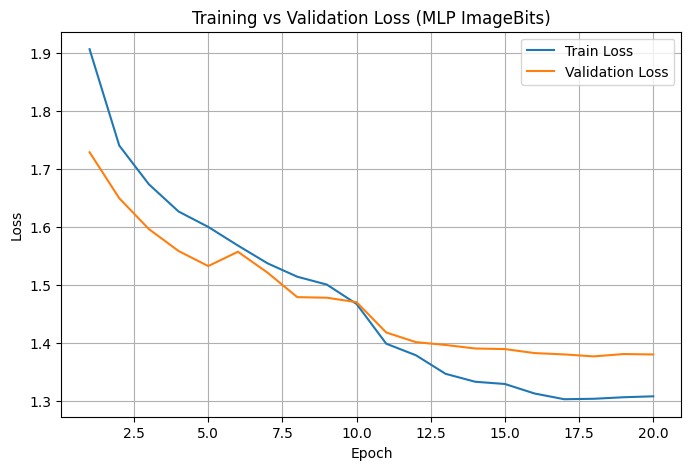

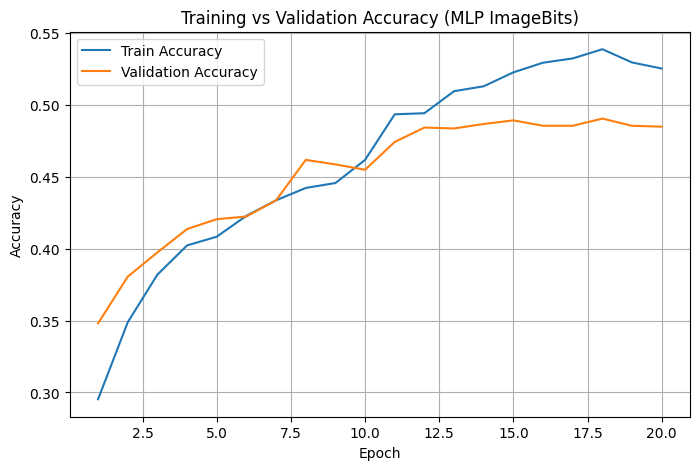

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (MLP ImageBits)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (MLP ImageBits)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return acc, f1


In [ ]:
test_acc, test_f1 = evaluate_model(model, test_loader_imagebits, device)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-score (macro): {test_f1:.4f}")


Test Accuracy: 0.4940
Test F1-score (macro): 0.4888


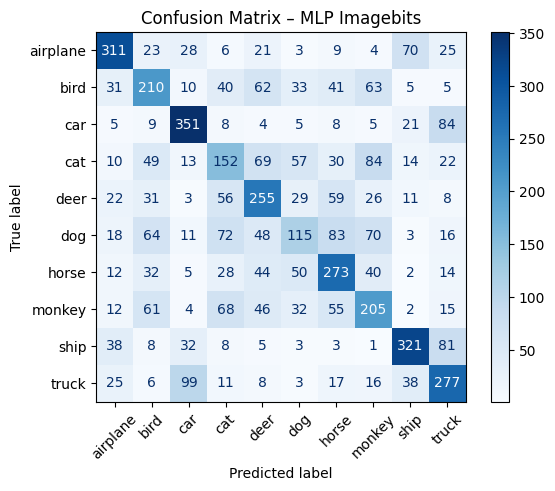

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataloader, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix – MLP Imagebits")
    plt.show()

plot_confusion_matrix(model, test_loader_imagebits, train_full_imagebits.classes)



#Landpatches

In [ ]:
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGEBITS_SIZE = 96
DATA_MEAN = (0.5, 0.5, 0.5)
DATA_STD  = (0.5, 0.5, 0.5)

USE_ALBUMENTATIONS_LAND = True

train_path_land_patches = "dataset_land_patches/land_patches/train"
val_path_land_patches   = "dataset_land_patches/land_patches/val"
test_path_land_patches  = "dataset_land_patches/land_patches/test"


transform_land = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(DATA_MEAN, DATA_STD)
])


albumentations_train_land = A.Compose([
    A.RandomResizedCrop(
        size=(96, 96),
        scale=(0.9, 1.0)
    ),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.Normalize(mean=DATA_MEAN, std=DATA_STD),
    ToTensorV2()
])

albumentations_test_land = A.Compose([
    A.Resize(height=96, width=96),
    A.Normalize(mean=DATA_MEAN, std=DATA_STD),
    ToTensorV2()
])

train_base_land = datasets.ImageFolder(root=train_path_land_patches, transform=None)
val_base_land   = datasets.ImageFolder(root=val_path_land_patches, transform=None)
test_base_land  = datasets.ImageFolder(root=test_path_land_patches, transform=None)



if USE_ALBUMENTATIONS_LAND:
    train_dataset_land = AlbumentationsImageFolder(
        train_base_land,
        transform=albumentations_train_land
    )

    val_dataset_land = AlbumentationsImageFolder(
        val_base_land,
        transform=albumentations_test_land
    )

    test_dataset_land = AlbumentationsImageFolder(
        test_base_land,
        transform=albumentations_test_land
    )

else:
    train_base_land.transform = transform_land
    val_base_land.transform   = transform_land
    test_base_land.transform  = transform_land

    train_dataset_land = train_base_land
    val_dataset_land   = val_base_land
    test_dataset_land  = test_base_land


train_loader_land = DataLoader(train_dataset_land, batch_size=8, shuffle=True)
val_loader_land   = DataLoader(val_dataset_land, batch_size=8, shuffle=False)
test_loader_land  = DataLoader(test_dataset_land, batch_size=8, shuffle=False)


In [ ]:
model = MLP_ImageBits(num_classes=10).to(device)

state_dict = torch.load("mlp_imagebits_pretrained.pth", map_location=device)

state_dict.pop("fc3.weight")
state_dict.pop("fc3.bias")

model.load_state_dict(state_dict, strict=False)


_IncompatibleKeys(missing_keys=['fc3.weight', 'fc3.bias'], unexpected_keys=[])

In [ ]:
for name, param in model.named_parameters():
    if not name.startswith("fc3"):
        param.requires_grad = False


criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=0
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[10, 15],
    gamma=0.1
)



In [ ]:
best_val_acc = 0.0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_land:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader_land)
    train_acc = correct / total

    val_loss, val_acc = evaluate_loss_and_acc(
        model, val_loader_land, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "mlp_landpatches_finetuned.pth")

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )


Epoch 01 | Train loss: 1.9136, acc: 0.2960 | Val loss: 1.5537, acc: 0.4550
Epoch 02 | Train loss: 1.7353, acc: 0.3730 | Val loss: 1.4667, acc: 0.4830
Epoch 03 | Train loss: 1.6872, acc: 0.3845 | Val loss: 1.4424, acc: 0.4640
Epoch 04 | Train loss: 1.6565, acc: 0.3875 | Val loss: 1.4058, acc: 0.5070
Epoch 05 | Train loss: 1.6655, acc: 0.3850 | Val loss: 1.3690, acc: 0.5340
Epoch 06 | Train loss: 1.6145, acc: 0.4185 | Val loss: 1.3388, acc: 0.5390
Epoch 07 | Train loss: 1.6431, acc: 0.4090 | Val loss: 1.3473, acc: 0.5480
Epoch 08 | Train loss: 1.6249, acc: 0.4125 | Val loss: 1.3232, acc: 0.5230
Epoch 09 | Train loss: 1.6181, acc: 0.4200 | Val loss: 1.3578, acc: 0.5140
Epoch 10 | Train loss: 1.6316, acc: 0.4075 | Val loss: 1.3229, acc: 0.5350
Epoch 11 | Train loss: 1.5795, acc: 0.4210 | Val loss: 1.2907, acc: 0.5650
Epoch 12 | Train loss: 1.5731, acc: 0.4345 | Val loss: 1.3018, acc: 0.5580
Epoch 13 | Train loss: 1.5571, acc: 0.4355 | Val loss: 1.2788, acc: 0.5650
Epoch 14 | Train loss: 1.

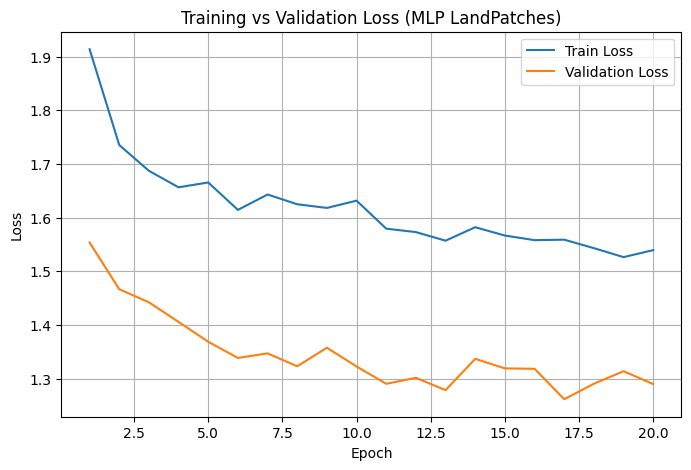

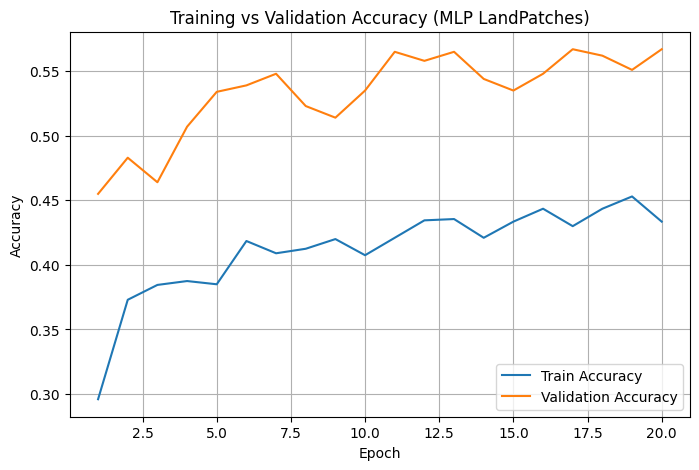

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (MLP LandPatches)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (MLP LandPatches)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model.load_state_dict(
    torch.load("mlp_landpatches_finetuned.pth", map_location=device)
)

test_acc, test_f1 = evaluate_model(
    model, test_loader_land, device
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-score (macro): {test_f1:.4f}")

Test Accuracy: 0.5674
Test F1-score (macro): 0.5480


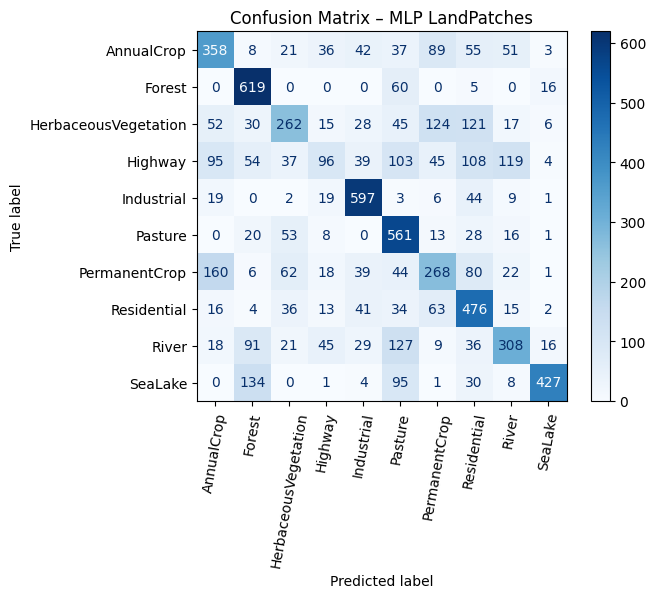

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataloader, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=80)
    plt.title("Confusion Matrix – MLP LandPatches")
    plt.show()

plot_confusion_matrix(model, test_loader_land, train_dataset_land_patches.classes)



#CNN

##Imagebits

In [ ]:
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGEBITS_SIZE = 96

DATA_MEAN = (0.5, 0.5, 0.5)
DATA_STD  = (0.5, 0.5, 0.5)

USE_ALBUMENTATIONS = False

transform_imagebits = transforms.Compose([
    transforms.Resize((IMAGEBITS_SIZE, IMAGEBITS_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(DATA_MEAN, DATA_STD)
])


albumentations_train_imagebits = A.Compose([
    A.RandomResizedCrop(
        size=(96, 96),
        scale=(0.8, 1.0)
    ),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
        p=0.5
    ),
    A.Normalize(mean=DATA_MEAN, std=DATA_STD),
    ToTensorV2()
])


albumentations_test_imagebits = A.Compose([
    A.Resize(height=96, width=96),
    A.Normalize(mean=DATA_MEAN, std=DATA_STD),
    ToTensorV2()
])


train_full_imagebits = datasets.ImageFolder(
    root=train_path_imagebits,
    transform=None
)

test_imagebits = datasets.ImageFolder(
    root=test_path_imagebits,
    transform=None
)

train_size_imagebits = int(0.8 * len(train_full_imagebits))
val_size_imagebits = len(train_full_imagebits) - train_size_imagebits

train_subset, val_subset = random_split(
    train_full_imagebits,
    [train_size_imagebits, val_size_imagebits]
)

if USE_ALBUMENTATIONS:
    train_dataset_imagebits = AlbumentationsImageFolder(
        train_subset,
        transform=albumentations_train_imagebits
    )

    val_dataset_imagebits = AlbumentationsImageFolder(
        val_subset,
        transform=albumentations_test_imagebits
    )

    test_dataset_imagebits = AlbumentationsImageFolder(
        test_imagebits,
        transform=albumentations_test_imagebits
    )

else:
    train_subset.dataset.transform = transform_imagebits
    val_subset.dataset.transform   = transform_imagebits
    test_imagebits.transform  = transform_imagebits

    train_dataset_imagebits = train_subset
    val_dataset_imagebits   = val_subset
    test_dataset_imagebits  = test_imagebits


train_loader_imagebits = DataLoader(train_dataset_imagebits, batch_size=64, shuffle=True)
val_loader_imagebits   = DataLoader(val_dataset_imagebits, batch_size=64, shuffle=False)
test_loader_imagebits  = DataLoader(test_dataset_imagebits, batch_size=64, shuffle=False)



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F



class CNN_ImageBits(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(128 * 12 * 12, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)

        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        return x





# class CNN_ImageBits(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()

#         # -------- Feature extractor --------
#         self.conv_block1 = nn.Sequential(
#             nn.Conv2d(3, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.MaxPool2d(2)   # 96 -> 48
#         )

#         self.conv_block2 = nn.Sequential(
#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d(2)   # 48 -> 24
#         )

#         self.conv_block3 = nn.Sequential(
#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.MaxPool2d(2)   # 24 -> 12
#         )

#         # -------- Classifier --------
#         self.flatten = nn.Flatten()

#         self.fc1 = nn.Linear(128 * 12 * 12, 512)
#         self.bn1 = nn.BatchNorm1d(512)

#         self.fc2 = nn.Linear(512, num_classes)

#         self.dropout = nn.Dropout(p=0.5)

#     def forward(self, x):
#         x = self.conv_block1(x)
#         x = self.conv_block2(x)
#         x = self.conv_block3(x)

#         x = self.flatten(x)

#         x = self.fc1(x)
#         x = self.bn1(x)
#         x = F.relu(x)
#         x = self.dropout(x)

#         x = self.fc2(x)
#         return x


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_ImageBits(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[10, 15],
    gamma=0.1
)

images, labels = next(iter(train_loader_imagebits))
images = images.to(device)

outputs = model(images)
print(outputs.shape)


torch.Size([64, 10])


In [ ]:
def evaluate_loss_and_acc(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    acc = correct / total
    return avg_loss, acc




train_losses, val_losses = [], []
train_accs, val_accs = [], []

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader_imagebits:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader_imagebits)
    train_acc = correct / total

    val_loss, val_acc = evaluate_loss_and_acc(
        model, val_loader_imagebits, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )

torch.save(model.state_dict(), "cnn_imagebits.pth")

Epoch 01 | Train loss: 1.8157, acc: 0.3153 | Val loss: 1.4985, acc: 0.4469
Epoch 02 | Train loss: 1.4566, acc: 0.4597 | Val loss: 1.3725, acc: 0.5019
Epoch 03 | Train loss: 1.2628, acc: 0.5355 | Val loss: 1.2286, acc: 0.5487
Epoch 04 | Train loss: 1.0797, acc: 0.6128 | Val loss: 1.1354, acc: 0.5988
Epoch 05 | Train loss: 0.9191, acc: 0.6636 | Val loss: 1.1514, acc: 0.6050
Epoch 06 | Train loss: 0.7677, acc: 0.7248 | Val loss: 1.1214, acc: 0.6206
Epoch 07 | Train loss: 0.5995, acc: 0.7858 | Val loss: 1.1063, acc: 0.6288
Epoch 08 | Train loss: 0.4644, acc: 0.8336 | Val loss: 1.2329, acc: 0.6244
Epoch 09 | Train loss: 0.3758, acc: 0.8705 | Val loss: 1.2678, acc: 0.6294
Epoch 10 | Train loss: 0.2765, acc: 0.9039 | Val loss: 1.4252, acc: 0.6281
Epoch 11 | Train loss: 0.1476, acc: 0.9541 | Val loss: 1.3506, acc: 0.6550
Epoch 12 | Train loss: 0.1179, acc: 0.9625 | Val loss: 1.4038, acc: 0.6481
Epoch 13 | Train loss: 0.1018, acc: 0.9705 | Val loss: 1.4559, acc: 0.6475
Epoch 14 | Train loss: 0.

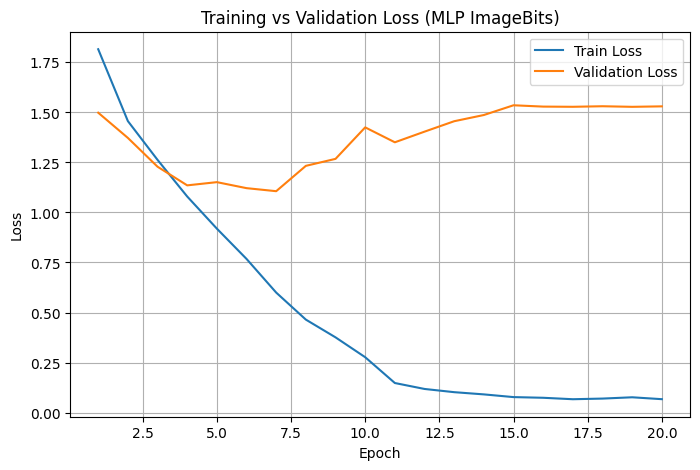

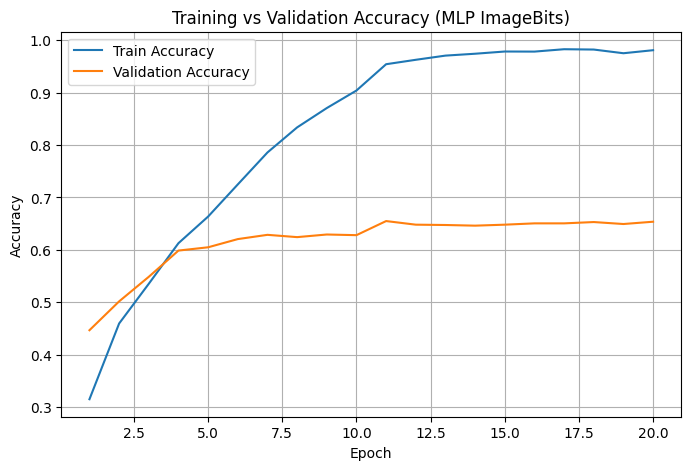

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (MLP ImageBits)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (MLP ImageBits)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
test_acc, test_f1 = evaluate_model(model, test_loader_imagebits, device)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-score (macro): {test_f1:.4f}")


Test Accuracy: 0.6648
Test F1-score (macro): 0.6648


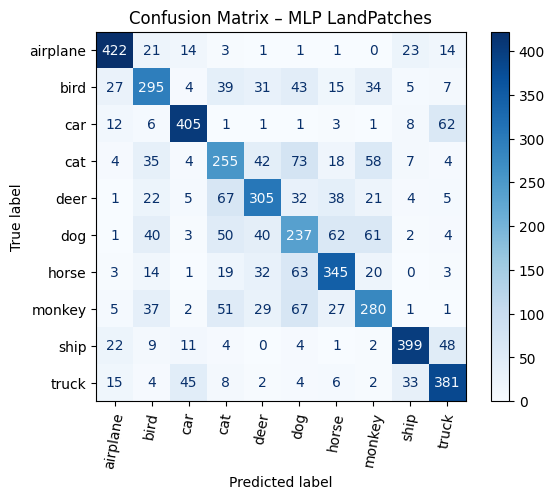

In [ ]:
plot_confusion_matrix(model, test_loader_imagebits, train_full_imagebits.classes)

#Landpatches

In [ ]:
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGEBITS_SIZE = 96
DATA_MEAN = (0.5, 0.5, 0.5)
DATA_STD  = (0.5, 0.5, 0.5)


train_path_land_patches = "dataset_land_patches/land_patches/train"
val_path_land_patches   = "dataset_land_patches/land_patches/val"
test_path_land_patches  = "dataset_land_patches/land_patches/test"


transform_land = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(DATA_MEAN, DATA_STD)
])


albumentations_train_land = A.Compose([
    A.RandomResizedCrop(
        size=(96, 96),
        scale=(0.9, 1.0)
    ),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.Normalize(mean=DATA_MEAN, std=DATA_STD),
    ToTensorV2()
])

albumentations_test_land = A.Compose([
    A.Resize(height=96, width=96),
    A.Normalize(mean=DATA_MEAN, std=DATA_STD),
    ToTensorV2()
])

train_base_land = datasets.ImageFolder(root=train_path_land_patches, transform=None)
val_base_land   = datasets.ImageFolder(root=val_path_land_patches, transform=None)
test_base_land  = datasets.ImageFolder(root=test_path_land_patches, transform=None)



if USE_ALBUMENTATIONS:
    train_dataset_land = AlbumentationsImageFolder(
        train_base_land,
        transform=albumentations_train_land
    )

    val_dataset_land = AlbumentationsImageFolder(
        val_base_land,
        transform=albumentations_test_land
    )

    test_dataset_land = AlbumentationsImageFolder(
        test_base_land,
        transform=albumentations_test_land
    )

else:
    train_base_land.transform = transform_land
    val_base_land.transform   = transform_land
    test_base_land.transform  = transform_land

    train_dataset_land = train_base_land
    val_dataset_land   = val_base_land
    test_dataset_land  = test_base_land


train_loader_land = DataLoader(train_dataset_land, batch_size=8, shuffle=True)
val_loader_land   = DataLoader(val_dataset_land, batch_size=8, shuffle=False)
test_loader_land  = DataLoader(test_dataset_land, batch_size=8, shuffle=False)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_ImageBits(num_classes=10).to(device)

state_dict = torch.load("cnn_imagebits.pth", map_location=device)


state_dict.pop("fc2.weight")
state_dict.pop("fc2.bias")

model.load_state_dict(state_dict, strict=False)


_IncompatibleKeys(missing_keys=['fc2.weight', 'fc2.bias'], unexpected_keys=[])

In [ ]:
for name, param in model.named_parameters():
    if not name.startswith("fc"):
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[10, 15],
    gamma=0.1
)


In [ ]:
best_val_acc = 0.0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

EPOCHS = 20

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_land:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader_land)
    train_acc = correct / total

    val_loss, val_acc = evaluate_loss_and_acc(
        model, val_loader_land, criterion, device
    )

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "cnn_landpatches_finetuned.pth")

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}"
    )


Epoch 01 | Train loss: 1.3364, acc: 0.5280 | Val loss: 0.7941, acc: 0.7300
Epoch 02 | Train loss: 0.7929, acc: 0.7325 | Val loss: 0.7541, acc: 0.7340
Epoch 03 | Train loss: 0.6674, acc: 0.7780 | Val loss: 0.7110, acc: 0.7330
Epoch 04 | Train loss: 0.5307, acc: 0.8245 | Val loss: 0.6866, acc: 0.7650
Epoch 05 | Train loss: 0.4398, acc: 0.8620 | Val loss: 0.7196, acc: 0.7590
Epoch 06 | Train loss: 0.4091, acc: 0.8665 | Val loss: 0.8500, acc: 0.6930
Epoch 07 | Train loss: 0.3851, acc: 0.8720 | Val loss: 0.7273, acc: 0.7600
Epoch 08 | Train loss: 0.3711, acc: 0.8755 | Val loss: 0.7062, acc: 0.7730
Epoch 09 | Train loss: 0.3721, acc: 0.8665 | Val loss: 0.7319, acc: 0.7640
Epoch 10 | Train loss: 0.3522, acc: 0.8890 | Val loss: 0.7500, acc: 0.7590
Epoch 11 | Train loss: 0.2854, acc: 0.9085 | Val loss: 0.6954, acc: 0.7700
Epoch 12 | Train loss: 0.2416, acc: 0.9275 | Val loss: 0.7486, acc: 0.7590
Epoch 13 | Train loss: 0.2137, acc: 0.9300 | Val loss: 0.7234, acc: 0.7710
Epoch 14 | Train loss: 0.

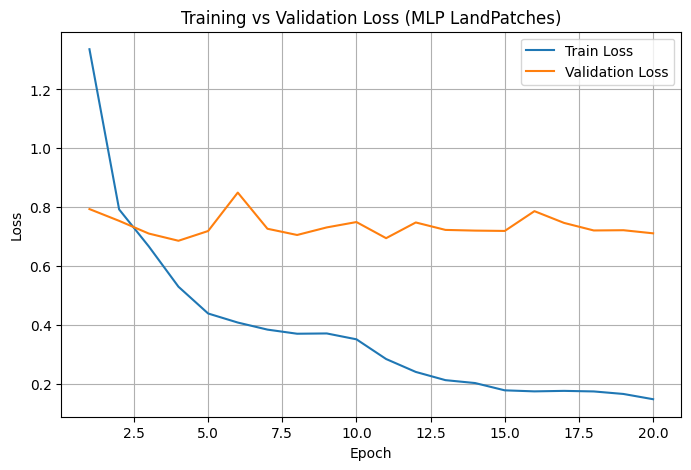

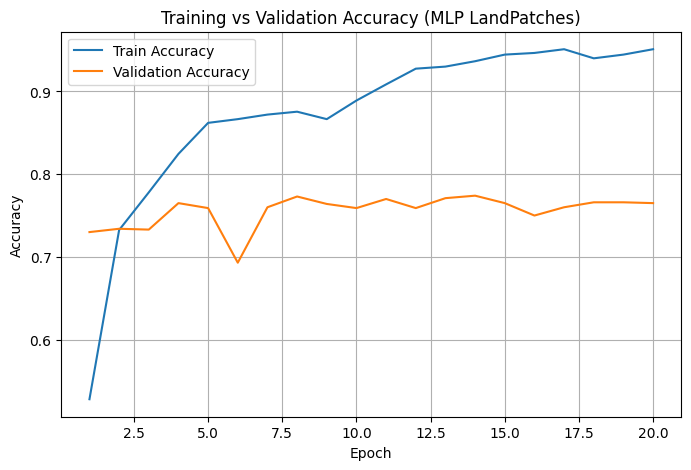

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (MLP LandPatches)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, train_accs, label="Train Accuracy")
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (MLP LandPatches)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

model.load_state_dict(
    torch.load("cnn_landpatches_finetuned.pth", map_location=device)
)

test_acc, test_f1 = evaluate_model(
    model, test_loader_land, device
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-score (macro): {test_f1:.4f}")

Test Accuracy: 0.7690
Test F1-score (macro): 0.7637


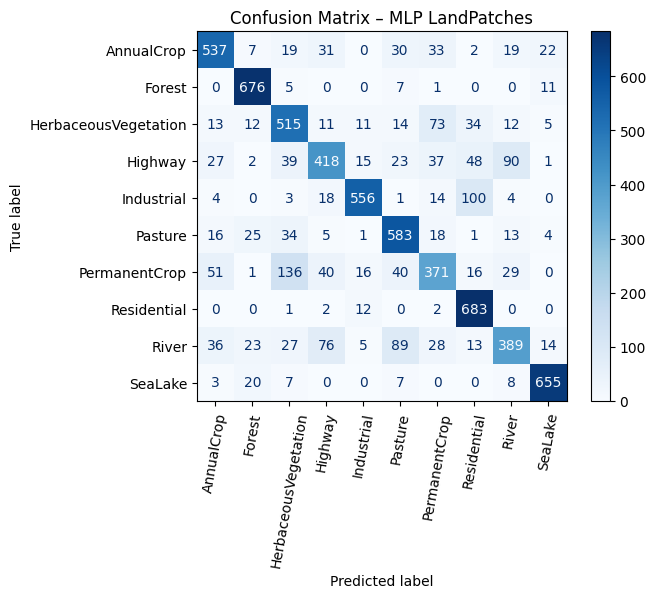

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, dataloader, class_names):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap="Blues", xticks_rotation=80)
    plt.title("Confusion Matrix – MLP LandPatches")
    plt.show()

plot_confusion_matrix(model, test_loader_land, train_dataset_land_patches.classes)

